In [1]:
using QuadGK,LaTeXStrings,LinearAlgebra,BenchmarkTools;
using Plots,CSV,DataFrames;
import NLsolve,Roots;
import Optim;

In [14]:
pyplot(frame=:box, minorticks=5, size=(400,300), fontfamily="serif",titlefontsize=11
    ,guidefontsize=12,tickfontsize=11,legendfontsize=9,
    bg_color_legend = RGBA(1,1,1,0.15), markerstrokecolor= :auto);
# gr(frame=:box, minorticks=5, size=(400,300));

In [3]:
include("./libs/constants.jl");
include("./libs/pwa.jl");
include("./libs/potentials.jl");

In [4]:
λf(x, y, z) = x^2 + y^2 + z^2 - 2 * x * y - 2 * x * z - 2 * y * z
q0f(E, m1, m2, m3, m4) = abs(m3^2 - m4^2 - m1^2 + m2^2) / (2 * E)
μf(m1, m2) = m1 * m2 / (m1 + m2)

# redefine sqrt so that its cut is along the positive x axis
function xsqrt(x)
    imag(x) >=0 ? sqrt(x+0im) : -sqrt(x-0im)
end
xsqrt1(x)= (imag(x)<0&&real(x)>0) ? -xsqrt(x) : xsqrt(x)

xsqrt1 (generic function with 1 method)

In [5]:

#https://github.com/fkguo/IMinuit.jl/blob/master/src/Data.jl
# check whether the data are valid for a fit
function check_data(xdata, ydata, errdata)
    if any(ismissing, xdata) || any(ismissing, ydata) || any(ismissing, errdata)
        error("Error: Data contain `missing` values.")
    end
    if any(isinf, xdata) || any(isinf, ydata) || any(isnan, xdata) || any(isnan, ydata) || any(isnan, errdata)
        error("Error: Data contain `Inf` or `NaN` values.")
    end
    if any(iszero, errdata)
        error("Error: Data contain 0 in the errors.")
    end
end

"""
    Data(x::T, y::T, err::T) where {T<:Vector{Real}}
    Data(df::DataFrame)
Fields: `x, y, err, ndata`
This defines a type for data with three columns:` x, y, err`; `ndata` is the number of data rows.
Different `Data` sets can be concatenated as `vcat(dat1, dat2, dat3)`.
Only symmetric errors (of `y`) are supported.
"""
struct Data
    x::Vector{Float64}
    y::Vector{Float64}
    err::Vector{Float64}
    ndata::Int
    function Data(x, y, err) # Data(x::Vector{T}, y::Vector{T}, err::Vector{T}) where {T<:Real}
        check_data(x, y, err)
        ndata = length(x)
        new(x, y, err, ndata)
    end
end

Data(df::DataFrame) = Data(df[:,1], df[:,2], df[:,3])

import Base.vcat, Base.getindex
vcat(dat1::Data, dat2::Data) = Data(vcat(dat1.x, dat2.x), vcat(dat1.y, dat2.y), vcat(dat1.err, dat2.err))
vcat(dat1::Data, dat...) = reduce(vcat, [dat1, dat...])
getindex(data::Data, in) = Data(map(x-> getindex(x, in), (data.x, data.y, data.err))...)

"""
    @plt_data(data, kws...)
    @plt_data!(data, kws...)
Convenient mascros to make an errorbar plot of the `data`; all combinations of
keyword settings for `scatter` in `Plots` can be used for the optional arguments `kws...`
"""
macro plt_data(data, kws...)
    _plt = quote
        if isempty($kws)
            Plots.scatter($data.x, $data.y, yerror = $data.err,
            xlab = "x", ylab = "y", label = "Data")
        else
            Plots.scatter($data.x, $data.y, yerror = $data.err; $(kws...) )
        end
    end
    return esc(_plt)
end
macro plt_data!(data, kws...)
    _plt = quote
        if isempty($kws)
            Plots.scatter!($data.x, $data.y, yerror = $data.err,
            xlab = "x", ylab = "y", label = "Data")
        else
            Plots.scatter!($data.x, $data.y, yerror = $data.err; $(kws...) )
        end
    end
    return esc(_plt)
end

@doc raw"""
    chisq(dist::Function, data, par; fitrange = ())
defines the ``\chi^2`` function: `fun` the function to be fitted to the data given by `data`.
The parameters are collected into `par`, given as an array or a tuple.
* `data` can be either given as the `Data` type, or of the form `(xdata, ydata [, err])`.
If no `err` is given explicitly, the errors are assumed to be 1 for all data points.
* `fitrange`: default to the whole data set; may given as, e.g., `2:10`,
which means only fitting to the 2nd to the 10th data points.
"""
function chisq(dist::Function, data::Data, par; fitrange = ())
    fitrange = (isempty(fitrange) ? (1:data.ndata) : fitrange)
    # __dist__(x, par) = (length(func_argnames(dist)) > 2 ? dist(x, par...) : dist(x, par) )
    res = 0.0
    @simd for i = fitrange[1]:fitrange[end]
        @inbounds res += ( (data.y[i]- dist(data.x[i], par))/data.err[i] )^2
    end
    return res
end
# function chisq(dist::Function, data::Data, par::Tuple; fitrange = ())
#     fitrange = (isempty(fitrange) && 1:data.ndata)
#     res = 0.0
#     @simd for i = fitrange
#         @inbounds res += ( (data.y[i]- dist(data.x[i], par))/data.err[i] )^2
#     end
#     return res
# end
function chisq(dist::Function, data, par; fitrange = ())
    _x = data[1]; _y = data[2]
    _n = length(_x)
    _err = (length(data) == 2 ? ones(_n) : data[3])
    fitrange = (isempty(fitrange) ? (1:data.ndata) : fitrange)
    # __dist__(x, par) = (length(func_argnames(dist)) > 2 ? dist(x, par...) : dist(x, par) )
    res = 0.0
    @simd for i = fitrange[1]:fitrange[end]
        @inbounds res += ( (_y[i]- dist(_x[i], par))/_err[i] )^2
    end
    return res
end

"""
    @plt_best(dist, fit, data, kws...)
    @plt_best!(dist, fit, data, kws...)
A convenient macro for comparing the best-fit result with the data; all combinations of
keyword settings for `plot` in `Plots` can be used for the optional arguments `kws...`
The ordering of `dist`, `fit`, and `data` does not matter.
"""
macro plt_best(dist, fit, data, kws...)
    _expr = quote
        _arr = [$dist, $fit, $data]
        _fit = _arr[findfirst(x->typeof(x) <:AbstractFit, _arr)]
        _dist = _arr[findfirst(x->typeof(x) <:Function, _arr)]
        _data = _arr[findfirst(x->typeof(x) <:Data, _arr)]

        _npts = 100
        _paras = args(_fit)
        _dis(x) = (typeof(_fit) == ArrayFit ? _dist(x, _paras) : _dist(x, _paras...) )
        _xrange = _data.x
        _wv = LinRange(_xrange[1], _xrange[end], _npts)

        Plots.scatter($data.x, $data.y, yerror = $data.err, label = "Data")
        if isempty($kws)
            Plots.plot!(_wv, _dis.(_wv), xlab = "x", ylab = "y", label = "Best fit", lw = 1.5 )
        else
            Plots.plot!(_wv, _dis.(_wv); $(kws...)  )
        end
    end
    esc( _expr )
end

macro plt_best!(dist, fit, data, kws...)
    _expr = quote
        _arr = [$dist, $fit, $data]
        _fit = _arr[findfirst(x->typeof(x) <:AbstractFit, _arr)]
        _dist = _arr[findfirst(x->typeof(x) <:Function, _arr)]
        _data = _arr[findfirst(x->typeof(x) <:Data, _arr)]

        _npts = 100
        _paras = args(_fit)
        _dis(x) = (typeof(_fit) == ArrayFit ? _dist(x, _paras) : _dist(x, _paras...) )
        _xrange = _data.x
        _wv = LinRange(_xrange[1], _xrange[end], _npts)

        Plots.scatter!($data.x, $data.y, yerror = $data.err, label = "Data")
        if isempty($kws)
            Plots.plot!(_wv, _dis.(_wv), xlab = "x", ylab = "y", label = "Best fit", lw = 1.5 )
        else
            Plots.plot!(_wv, _dis.(_wv); $(kws...)  )
        end
    end
    esc( _expr )
end

function quadgauss(f, x::T, w::T) where {T<:Vector{Float64}}
    res = zero(f(x[1]))  # zero of the same type as f(x[1]), to avoid type instability
    for i in eachindex(x)
        res += f(x[i]) * w[i]
    end
    return res
end

quadgauss (generic function with 1 method)

In [6]:
function Γf(E,q,m1,m2,m3,m12)
    E1=E+m12-sqrt(m12^2+q^2+0im)-sqrt(m3^2+q^2+0im)
    μ=(m1*m2)/(m1+m2)
    return (imag(E1)<0&&real(E1)>(m1+m2)) ? -xsqrt(2*μ*(E1-m1-m2)+0im) : xsqrt(2*μ*(E1-m1-m2)+0im)
end

function Γf3(E,q,m1,m2,m3,m12)
    E1=E+m12-sqrt(m12^2+q^2+0im)-sqrt(m3^2+q^2+0im)
    μ=(m1*m2)/(m1+m2)
    return (imag(E1)<0&&real(E1)>(m1+m2)) ? -xsqrt(2*μ*(E1-m1-m2)+0im)^3 : xsqrt(2*μ*(E1-m1-m2)+0im)^3
end

function dΓf3(E,q,m1,m2,m3,m12)
    E1=E+m12-sqrt(m12^2+q^2+0im)-sqrt(m3^2+q^2+0im)
    μ=(m1*m2)/(m1+m2)
    tmp=-3*μ*xsqrt(2*μ*(E1-m1-m2)+0im)*(q/sqrt(m12^2+q^2+0im)+q/sqrt(m3^2+q^2+0im))
    return (imag(E1)<0&&real(E1)>(m1+m2)) ? -tmp : tmp
end

ΓDscf(E, p) = (ΓRDsc + g^2 * mDn / (6 * π * fπ^2 * mDsc) * Γf3(E, p, mDn, mπc, mDn,mDsc)
                                   + g^2 * mDc / (12 * π * fπ^2 * mDsc) * Γf3(E, p, mDc, mπn, mDn,mDsc))

ΓDsnf(E, p) = (ΓRDsn + g^2 * mDn / (12 * π * fπ^2 * mDsn) * Γf3(E, p, mDn, mπn, mDc,mDsn)
                                   + g^2 * mDc / (6 * π * fπ^2 * mDsn) * (Γf3(E, p, mDc, mπc, mDc,mDsn) - Γf3(mDc + mDsn, 0, mDc, mπc, mDc,mDsn)))

dΓDscf(E, p) = (g^2 * mDn / (6 * π * fπ^2 * mDsc) * dΓf3(E, p, mDn, mπc, mDn,mDsc)
                                   + g^2 * mDc / (12 * π * fπ^2 * mDsc) * dΓf3(E, p, mDc, mπn, mDn,mDsc))

dΓDsnf(E, p) = (g^2 * mDn / (12 * π * fπ^2 * mDsn) * dΓf3(E, p, mDn, mπn, mDc,mDsn)+ g^2 * mDc / (6 * π * fπ^2 * mDsn) * dΓf3(E, p, mDc, mπc, mDc,mDsn))

function find_singular(E, den; pstart = [0.01, 0.01])
    function f!(F, x)
        pr, pi = x
        tmp = den(E, pr + im * pi)
        F[1] = real(tmp)
        F[2] = imag(tmp)
    end
    sol = NLsolve.nlsolve((F, x) -> f!(F, x), pstart)
    return sol.zero[1] + im * sol.zero[2]
end
qon_c(E)=find_singular(E, (E, p) -> E-mDn-mDsc - p^2 / (2 * μf(mDn, mDsc)) + im * ΓDscf(E, p) / 2; pstart = [reim(xsqrt1(E-mDn-mDsc + im * ΓDsc / 2))...])

qon_0(E)=find_singular(E, (E, p) -> E-mDc-mDsn - p^2 / (2 * μf(mDc, mDsn)) + im * ΓDsnf(E, p) / 2; pstart = [reim(xsqrt1(E-mDc-mDsn + im * ΓDsn / 2))...])

qon_0 (generic function with 1 method)

In [7]:
xxx,www=gauss(96,0,1);

qi=zeros(ComplexF64,2+2*length(xxx));
wi=zeros(ComplexF64,length(xxx));
len=length(xxx);
sublen=length(qi);

In [8]:
Γsmc(t,Λ,ω,V0)=t+im*V0*(1-exp(-t/ω))*(1-exp((t-Λ)/ω))
dΓsmc(t,Λ,ω,V0)=1+im*V0/ω*(exp(-t/ω)-exp((t-Λ)/ω))

dΓsmc (generic function with 1 method)

In [9]:
Γsmcx(x,Λ,ω,V0)=Γsmc(Λ*x,Λ,ω,V0) #0~x~1
dΓsmcx(x,Λ,ω,V0)=Λ*dΓsmc(Λ*x,Λ,ω,V0)

dΓsmcx (generic function with 1 method)

# VGT

In [10]:
function getqw(E,Λ;ω=0.1,V0=-0.1,qi=qi,wi=wi)
    pmax=sqrt(abs(λf(E^2,mDn^2,(mπc+mDn)^2)))/(2*E)
    qi[1],qi[2]=qon_c(E),qon_0(E)
    for i in eachindex(xxx)
        qi[2+i]=pmax*xxx[i]
        qi[2+len+i]=Γsmcx(xxx[i],Λ,ω,V0)
        wi[i]=dΓsmcx(xxx[i],Λ,ω,V0)*www[i]
    end
    nothing
end

getqw (generic function with 1 method)

In [11]:
getqw(mDn+mDsc-360e-6-im*24e-6,0.6)

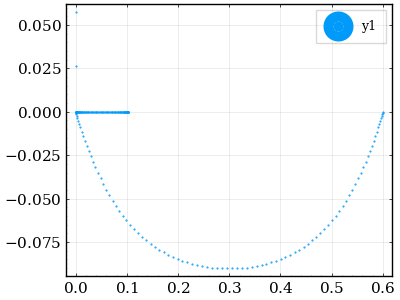

sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


In [15]:
scatter(real.(qi[1:end]),imag.(qi[1:end]),markersize=0.5)

In [16]:
Vmat=zeros(ComplexF64,2*length(qi),2*length(qi));
Gmat=zeros(ComplexF64,2*length(qi),2*length(qi));
Tmat=zeros(ComplexF64,2*length(qi),2*length(qi));

In [17]:
function VMat!(E;Λ=0.5,Cv = 0.0,Cp=0.0,I=0,plist=qi,des=Vmat)
    getqw(E,Λ)

    for l in eachindex(plist)
        for m in eachindex(plist)
            i, j = 1, 1
            des[sublen*(i-1)+l, sublen*(j-1)+m] = potential_DnDsc(E,plist[l], plist[m]; Cv=Cv,Cp=Cp,I=I,isπ=false)
            i, j = 1, 2
            des[sublen*(i-1)+l, sublen*(j-1)+m] = potential_DDscross(E,plist[l], plist[m];  Cv=Cv,Cp=Cp,I=I,isπ=false)
            i, j = 2, 1
            des[sublen*(i-1)+l, sublen*(j-1)+m] = potential_DDscross(E,plist[l], plist[m];  Cv=Cv,Cp=Cp,I=I,isπ=false)
            i, j = 2, 2
            des[sublen*(i-1)+l, sublen*(j-1)+m] = potential_DcDsn(E,plist[l], plist[m];  Cv=Cv,Cp=Cp,I=I,isπ=false)
        end
    end
    return nothing
end

VMat! (generic function with 1 method)

In [18]:
VMat!(3.875)

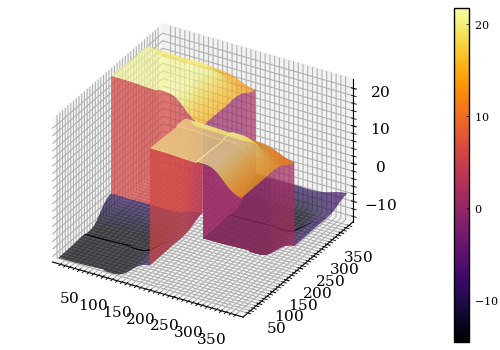

In [15]:
surface(collect(1:2*length(qi)),collect(1:2*length(qi)),[real(Vmat[x,y]) for y in 1:2*length(qi),x in 1:2*length(qi)])

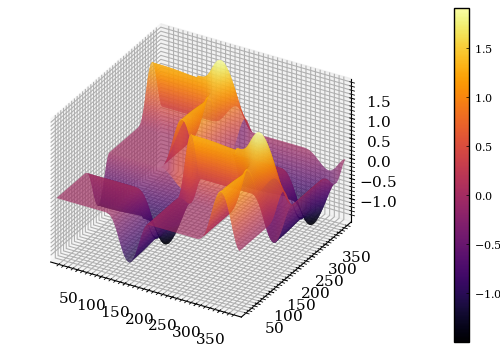

In [16]:
surface(collect(1:2*length(qi)),collect(1:2*length(qi)),[imag(Vmat[x,y]) for y in 1:2*length(qi),x in 1:2*length(qi)])

In [19]:
Gc(E,q)=1/(2π^2)/(E-mDn-mDsc-q^2/(2*μf(mDn,mDsc))+im*ΓDscf(E,q)/2)
Gn(E,q)=1/(2π^2)/(E-mDc-mDsn-q^2/(2*μf(mDc,mDsn))+im*ΓDsnf(E,q)/2)

Gn (generic function with 1 method)

In [20]:
function GMat!(E;Λ=0.5,qi=qi,wi=wi,des=Gmat)
    getqw(E,Λ)
    
    i=1
    for j in eachindex(wi)
        des[(i-1)*sublen+2+len+j,(i-1)*sublen+2+len+j]=wi[j]*qi[2+len+j]^2*Gc(E,qi[2+len+j])
    end
    
    i=2
    for j in eachindex(wi)
        des[(i-1)*sublen+2+len+j,(i-1)*sublen+2+len+j]=wi[j]*qi[2+len+j]^2*Gn(E,qi[2+len+j])
    end
    
    return nothing
end

GMat! (generic function with 1 method)

In [21]:
function detVG(E;Λ=0.5,Cv=0.0,Cp=0.0,I=0)
    VMat!(E;Λ=Λ,Cv=Cv,Cp=Cp,I=I)
    GMat!(E;Λ=Λ)
    return det(LinearAlgebra.I-Vmat*Gmat)
end

detVG (generic function with 1 method)

In [22]:
function TMat!(E;Λ=0.5,Cv=0.0,Cp=0.0,I=0,des=Tmat)
    VMat!(E;Λ=Λ,Cv=Cv,Cp=Cp,I=I)
    GMat!(E;Λ=Λ)
    des .=inv(LinearAlgebra.I-Vmat*Gmat)*Vmat
    nothing
end

TMat! (generic function with 1 method)

In [21]:
# @btime 
TMat!(3.875)

  61.548 ms (4672 allocations: 9.68 MiB)


In [19]:
let 
    function inv_abst(x;E=mDn+mDsc-273e-6,I=0)
        TMat!(E;Λ=x[1],I=I)
        return 1/abs(Tmat[1,1])
    end
    
    tmpf(x)=inv_abst(x)
    init_val=[0.5]
    lower=[0.3]
    upper=[1.2]
    res=Optim.optimize(tmpf,lower,upper,init_val)
    println(Optim.minimum(res))
    println(Optim.minimizer(res))
end

0.0001621807842692966
[0.3879110641022059]


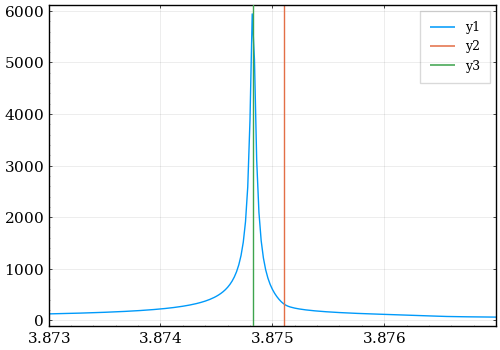

In [23]:
let Ev=collect(3.873:0.00002:3.877)
    function tmpf(E)
        TMat!(E;Λ=0.38791106410220616)
        abs(Tmat[1,1])
    end
    resv=[tmpf(e) for e in Ev]
    plot(Ev,resv,xlims=(3.873,3.877))
    vline!([mDn+mDsc])
    vline!([mDn+mDsc-273e-6])
end

# Extract pole position

In [23]:
function find_poles(pars)
    _lam,_Cv,_Cp=pars
    function f!(F, x)
        e, γ = x
        tmp = detVG(e + im * γ; Λ = _lam,Cv=_Cv,Cp=_Cp)
        F[1] = real(tmp)
        F[2] = imag(tmp)
    end
    tmp=NLsolve.nlsolve((F, x) -> f!(F, x), [mDn + mDsc - 333e-6, -24e-6])
#     (tmp.zero[1]-mDn-mDsc)+im*tmp.zero[2]
    return tmp.residual_norm <1e-8 ? (tmp.zero[1]-mDn-mDsc)+im*tmp.zero[2] : NaN+im*NaN
end

find_poles (generic function with 1 method)

In [24]:
find_poles([0.38791106410220616,0.0,0.0])

-0.0002738606378316355 - 2.0425143214908088e-5im

In [24]:
3.8748261393621686-mDn-mDsc

-0.0002738606378316355

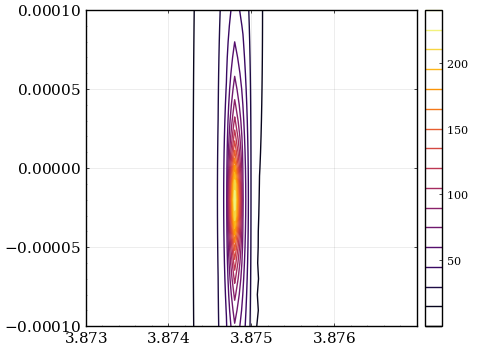

sys:1: UserWarning: The following kwargs were not used by contour: 'label'


In [28]:
let Ev=collect(3.873:0.0001:3.877),Γv=collect(-100e-6:10e-6:100e-6)
    resv=[1/abs(detVG(e+im*γ;Λ=0.38791106410220616)) for γ in Γv,e in Ev]
    contour(Ev,Γv,resv,fill=false)
end

# Fitting

In [25]:
using Interpolations;

In [26]:
function maketmatrixf(E)
    tmatrix=zeros(ComplexF64,len)
    tmp=zero(ComplexF64)
    for k in 3:(2+len)
        tmp=1.0
        for i in eachindex(wi)
            tmp+=wi[i]*qi[2+len+i]^2*Gc(E,qi[2+len+i])*Tmat[k,2+len+i]
            tmp+=-wi[i]*qi[2+len+i]^2*Gn(E,qi[2+len+i])*Tmat[k,sublen+2+len+i]
        end
        tmatrix[k-2]=tmp
    end
    return LinearInterpolation(real.(qi[3:2+len]),tmatrix)
end

maketmatrixf (generic function with 1 method)

In [27]:
function Γ3f(E;Λ = 0.5,Cv=0.0,Cp=0.0)
     TMat!(E;Λ = Λ,Cv=Cv,Cp=Cp)

    res = 0.0
    μ1, μ2 = μf(mDn, mDsc), μf(mDc, mDsn)
    m1,m2,m3=mDn,mπc,mDn

    tmptmatrixf = maketmatrixf(E)
    tmatrixf(p) = (real(qi[3]) <= p && p <= real(qi[2+len])) ? tmptmatrixf(p) : 0.0
    for i in eachindex(xxx)
        for j in eachindex(xxx)
            x1, x2, w1, w2 = xxx[i], xxx[j], www[i], www[j]
            s23=(m2+m3)^2*(1-x1)+(E-m1)^2*x1
            s12_min=m1^2+m2^2-(s23-E^2+m1^2)*(s23+m2^2-m3^2)/(2*s23)-sqrt(abs(λf(s23,E^2,m1^2)*λf(s23,m2^2,m3^2)))/(2*s23)
            s12_max=m1^2+m2^2-(s23-E^2+m1^2)*(s23+m2^2-m3^2)/(2*s23)+sqrt(abs(λf(s23,E^2,m1^2)*λf(s23,m2^2,m3^2)))/(2*s23)
            s12=s12_min*(1-x2)+s12_max*x2
            q,qbar=sqrt(λf(s23,mπc^2,mDn^2))/(2*sqrt(s23)),sqrt(λf(s12,mDn^2,mπc^2))/(2*sqrt(s12))
            p,pbar=sqrt(λf(E^2,mDn^2,s23))/(2*E),sqrt(λf(E^2,mDn^2,s12))/(2*E)
            res+=w1*w2*abs((E-m1)^2-(m2+m3)^2)*abs(s12_max-s12_min)*abs(q*tmatrixf(p)*Gc(E,p)+qbar*tmatrixf(pbar)*Gc(E,pbar))^2
        end
    end
    return res
end

Γ3f (generic function with 1 method)

In [28]:
function Resolution(E, E1)
    σ1 = 1.05 * 263e-6
    σ2 = 2.413 * σ1
    α = 0.778
    gaussfunc(x, μ, σ) = 1 / sqrt(2 * π) / σ * exp(-(x - μ)^2 / (2 * σ^2))
    return α * gaussfunc(E, E1, σ1) + (1 - α) * gaussfunc(E, E1, σ2)
end

Resolution (generic function with 1 method)

## fitting

In [29]:
using PyCall;
import NLsolve;
piminuit=pyimport("iminuit");

In [30]:
let 
    data_ddπ_sub_df = DataFrame(CSV.File("./data/ddpi_sub_du.csv", header = ["x", "y"]));
    len=length(data_ddπ_sub_df.x)
    len1=Int64(len/3)
    xv=[3.8731+0.0002*(i-1) for i in 1:20]
    yv=[data_ddπ_sub_df.y[3*(i-1)+2] for i in 1:len1]
    wv=[abs(data_ddπ_sub_df.y[3*(i-1)+1]-data_ddπ_sub_df.y[3*(i-1)+3])/2 for i in 1:len1]
    global const data_ddπ_sub=Data(xv,yv,wv);
    nothing
end

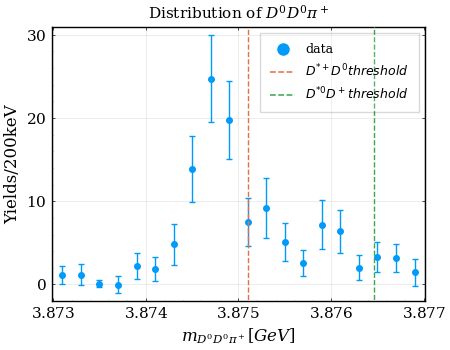

sys:1: UserWarning: You passed a edgecolor/edgecolors ((0.0, 0.6056031611752245, 0.9786801175696073, 1.0)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: You passed a edgecolor/edgecolors ((0.0, 0.6056031611752245, 0.9786801175696073, 1.0)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: You passed a edgecolor/edgecolors ((0.0, 0.6056031611752245, 0.9786801175696073, 1.0)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
sys:1: UserWarning: No data for colormapping provided via 'c'

In [31]:
@plt_data data_ddπ_sub title = L"Distribution of $D^0D^0\pi^+$" xlabel = L"m_{D^0D^0\pi^+}[GeV]" ylabel = "Yields/200keV" label = "data" size = (450, 350)
vline!([mDn + mDsc], ls = :dash, label = L"D^{*+}D^0 threshold")
vline!([mDc + mDsn], ls = :dash, label = L"D^{*0}D^+ threshold")

In [32]:
mutable struct distr
    Λ::Float64
    Cv::Float64
    Cp::Float64
    Γ3::Vector{Float64}
end

In [33]:
let Λ = 0.38791106410220616,Cv=0.0,Cp=0.0,Ev = range(3.873, 3.877, 100)
    resv = [Γ3f(e; Λ = Λ,Cv=Cv,Cp=Cp) for e in Ev]
    global distr_inst = distr(Λ,Cv,Cp, resv)
end

distr(0.38791106410220616, 0.0, 0.0, [0.003223148545864614, 0.003501932017858453, 0.0038078573480793704, 0.004144049791755232, 0.004514065615190141, 0.004921962688925747, 0.005372384629760986, 0.005870661500658486, 0.006422930842535934, 0.007036283797460815  …  0.6430547173979193, 0.6440856081986068, 0.6892341961577021, 0.6084941968870814, 0.5863219828053657, 0.6526405663959063, 0.5978846335993102, 0.5417110730188017, 0.5980993493108919, 0.6081864504190697])

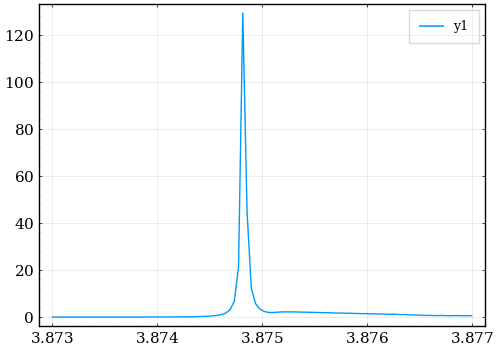

In [34]:
plot(range(3.873, 3.877, 100),distr_inst.Γ3)

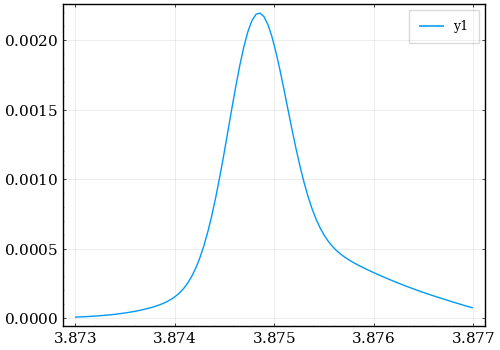

In [35]:
let
    Ev = range(3.873, 3.877, 100)
    Emin, Emax = Ev[1], Ev[end]
    tmpΓ3f = LinearInterpolation(Ev, distr_inst.Γ3)
    
    tmpf(E) = quadgauss(x ->(Emax - Emin) * tmpΓ3f(Emin + (Emax - Emin) * x) * Resolution(Emin + (Emax - Emin) * x, E), xxx, www)

    ΔE=0.0002
    Ebin(E,x)=(E-ΔE/2)*(1-x)+(E+ΔE/2)*x 
    tmpf1(E)=quadgauss(x->ΔE*tmpf(Ebin(E,x)),xxx,www)
    plot(Ev,tmpf1.(Ev))
end

In [34]:
function remake_distr(dis::distr, Λ,Cv,Cp)
    if Λ ≈ dis.Λ&&Cv≈dis.Cv&&Cp≈dis.Cp
        return false
    else
        Ev = range(3.873, 3.877, 100)
        for i in eachindex(dis.Γ3)
            dis.Γ3[i] = Γ3f(Ev[i];Λ = Λ,Cv=Cv,Cp=Cp)
        end
        dis.Λ = Λ
        dis.Cv=Cv 
        dis.Cp=Cp
    end
    return true
end

remake_distr (generic function with 1 method)

In [35]:
function dist(E, pars; dis = distr_inst, xx = xxx, ww = www)
    N, Λ,Cv,Cp = pars
    remake_distr(dis, Λ,Cv,Cp)
    Ev = range(3.873, 3.877, 100)
    Emin, Emax = Ev[1], Ev[end]
    tmpΓ3f = LinearInterpolation(Ev, dis.Γ3)
    
    tmpf(E) = quadgauss(x ->(Emax - Emin) * tmpΓ3f(Emin + (Emax - Emin) * x) * Resolution(Emin + (Emax - Emin) * x, E), xx, ww)

    ΔE=0.0002
    Ebin(E,x)=(E-ΔE/2)*(1-x)+(E+ΔE/2)*x
    return N * quadgauss(x->ΔE*tmpf(Ebin(E,x)),xx,ww)
end

dist (generic function with 1 method)

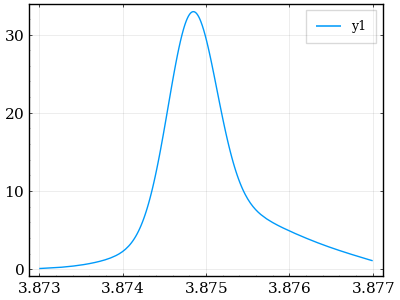

In [36]:
plot(e->dist(e,[1,0.38791106410220616,0.0,0.0])*30/0.002,3.873,3.877)

In [37]:
fcn(x,y,z,l; fitrange = ()) = chisq(dist, data_ddπ_sub,[x,y,z,l]; fitrange = fitrange)

fcn (generic function with 1 method)

## fitting results

In [37]:
let 
#     _n,_lam,_Cv,_Cp=[10000,0.4,0.0,0.0]
    _n,_lam,_Cv,_Cp=[8967.939568121186,0.39202714261761346,0.0,0.0]
    tmp_model=piminuit.Minuit(fcn,N=_n,lam=_lam,cv=_Cv,cp=_Cp,name=("N","lam","cv","cp"))
#     set!(tmp_model.limits,"N",(5000,15000))
#     set!(tmp_model.limits,"lam",(0.3,0.5))
    set!(tmp_model.fixed,"cv",true)
    set!(tmp_model.fixed,"cp",true)
    global fitres=piminuit.Minuit.migrad(tmp_model) 
end

PyObject <FMin algorithm='Migrad' edm=1.2975633830045807e-07 edm_goal=0.0002 errordef=1.0 fval=15.300245997611883 has_accurate_covar=True has_covariance=True has_made_posdef_covar=False has_parameters_at_limit=False has_posdef_covar=True has_reached_call_limit=False has_valid_parameters=True hesse_failed=False is_above_max_edm=False is_valid=True nfcn=27 ngrad=0 reduced_chi2=nan time=296.5359258749959>
(Param(number=0, name='N', value=8968.535830339271, error=976.8563471974417, merror=None, is_const=False, is_fixed=False, lower_limit=None, upper_limit=None), Param(number=1, name='lam', value=0.39202599413395567, error=0.0006102439572256021, merror=None, is_const=False, is_fixed=False, lower_limit=None, upper_limit=None), Param(number=2, name='cv', value=0.0, error=0.1, merror=None, is_const=False, is_fixed=True, lower_limit=None, upper_limit=None), Param(number=3, name='cp', value=0.0, error=0.1, merror=None, is_const=False, is_fixed=True, lower_limit=None, upper_limit=None))
[[9.54248323e+05 1.21955324e-01 0.00000000e+00 0.00000000e+00]
 [1.21955324e-01 3.72397687e-07 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]]

In [38]:
fitres.fval

15.300245997611883

In [39]:
15.3/(20-1)

0.8052631578947369

In [40]:
print(fitres.values)

PyObject <ValueView N=8968.535830339271 lam=0.39202599413395567 cv=0.0 cp=0.0>

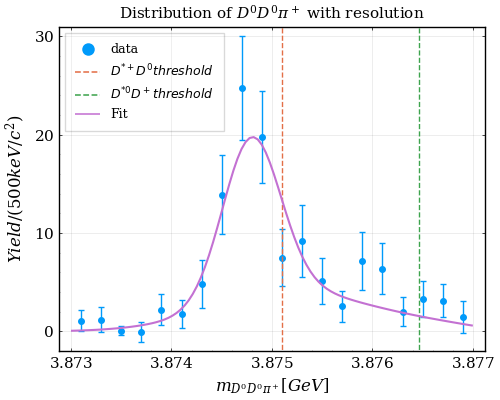

In [33]:
let
    Ev = range(3.873, 3.877, 100)
    @plt_data data_ddπ_sub title = L"Distribution of $D^0D^0\pi^+$ with resolution" xlabel = L"m_{D^0D^0\pi^+}[GeV]" ylabel = L"Yield/(500keV/c^2)" label = "data" size = (500, 400) legend = :topleft
    vline!([mDn + mDsc], ls = :dash, label = L"D^{*+}D^0 threshold")
    vline!([mDc + mDsn], ls = :dash, label = L"D^{*0}D^+ threshold")
    plot!(Ev, e -> dist(e, [8319.729255246895,0.38965965705223743,0.0,0.0]), lw = 1.5, label = "Fit")
end

In [41]:
find_poles([0.39202599413395567,0.0,0.0])

-0.0003473688219055582 - 1.871710114675906e-5im

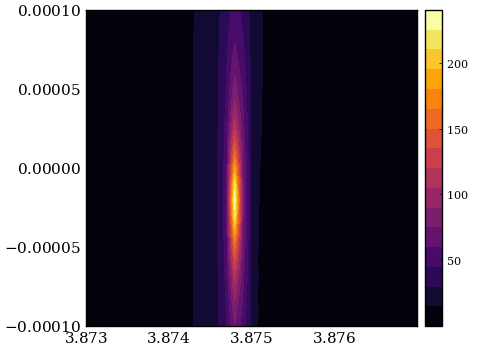

In [53]:
let Ev=collect(3.873:0.0001:3.877),Γv=collect(-100e-6:10e-6:100e-6)
    resv=[1/abs(detVG(e+im*γ;Λ=0.38790842627437616)) for γ in Γv,e in Ev]
    contour(Ev,Γv,resv,fill=true)
end

In [42]:
fitres.errors

PyObject <ErrorView N=976.8563471974417 lam=0.0006102439572256021 cv=0.1 cp=0.1>

In [43]:
find_poles([0.39202599413395567,0.0,0.0])

-0.0003473688219055582 - 1.871710114675906e-5im

In [44]:
find_poles([0.39202599413395567+0.0006102439572256021,0.0,0.0])|>println
find_poles([0.39202599413395567-0.0006102439572256021,0.0,0.0])|>println

-0.0003588537345136089 - 1.848128120796833e-5im
-0.00033603237143520204 - 1.895720300997288e-5im


In [45]:
-0.0003473688219055582 - 1.871710114675906e-5im-(-0.00033603237143520204 - 1.895720300997288e-5im)

-1.133645047035614e-5 + 2.4010186321382174e-7im

In [46]:
-0.0003588537345136089 - 1.848128120796833e-5im-(-0.0003473688219055582 - 1.871710114675906e-5im)

-1.1484912608050735e-5 + 2.3581993879072944e-7im

# Get data

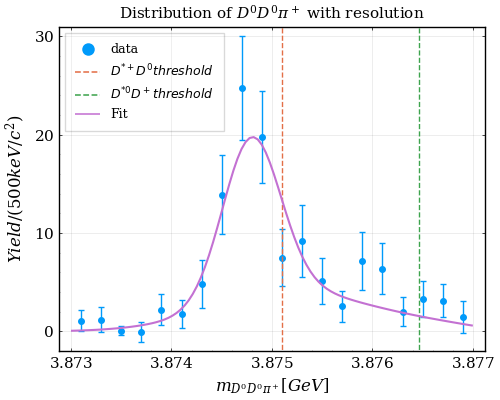

In [35]:
let
    Ev = range(3.873, 3.877, 100)
    @plt_data data_ddπ_sub title = L"Distribution of $D^0D^0\pi^+$ with resolution" xlabel = L"m_{D^0D^0\pi^+}[GeV]" ylabel = L"Yield/(500keV/c^2)" label = "data" size = (500, 400) legend = :topleft
    vline!([mDn + mDsc], ls = :dash, label = L"D^{*+}D^0 threshold")
    vline!([mDc + mDsn], ls = :dash, label = L"D^{*0}D^+ threshold")
    plot!(Ev, e -> dist(e, [8319.729255246895,0.38965965705223743,0.0,0.0]), lw = 1.5, label = "Fit")
end

In [36]:
let Ev = range(3.873, 3.877, 100)
    yields=[dist(e, [8319.729255246895,0.38965965705223743,0.0,0.0]) for e in Ev]
    df=DataFrame(X=Ev,Y=yields)
    CSV.write("./output/fit2.csv",df)
end

"./output/fit2.csv"

## test Cv

In [44]:
fitres_V=Array{Any}(undef,11);

In [45]:
for i in 1:11
    println(i)
    _n,_lam,_Cv,_Cp=[10000,0.4,0.1*(i-1),0.0]
    tmp_model=piminuit.Minuit(fcn,N=_n,lam=_lam,cv=_Cv,cp=_Cp,name=("N","lam","cv","cp"))
#     set!(tmp_model.limits,"N",(0,100000))
#     set!(tmp_model.limits,"lam",(0.3,2.0))
    set!(tmp_model.fixed,"cp",true)
    set!(tmp_model.fixed,"cv",true)
#     set!(tmp_model.fixed,"cp",true)
    fitres_V[i]=piminuit.Minuit.migrad(tmp_model)
end

1
2
3
4
5
6
7
8
9
10
11


In [46]:
[fitres_V[i].fval for i in 1:11]

11-element Vector{Float64}:
 16.315067773881434
 16.328708633272935
 16.012601782731736
 16.34732772995578
 15.31817029934202
 16.35168142339486
 18.242968089398307
 15.275292635130999
 34.8531602521741
 18.192431600434883
 15.245462381957028

In [49]:
for i in 1:11
    find_poles([fitres_V[i].values[2],fitres_V[i].values[3],0.0])|>println
end

-0.00030424848030596863 - 1.9673110737207594e-5im
-0.00030422926506723513 - 1.9615120440746275e-5im
-0.0003755956455027132 - 1.8046182998471177e-5im
-0.0003042666733890087 - 1.9511381945785736e-5im
-0.0003473468012393788 - 1.852292937971498e-5im
-0.00030420236549622004 - 1.9435484526299358e-5im
-0.00027324104286030604 - 2.0170226822136196e-5im
-0.00034734297006799864 - 1.8467540020051257e-5im
-0.0003183687036045768 - 1.9106575708048626e-5im
-0.0002735327085225947 - 2.0185899169526455e-5im
-0.0003473548580164021 - 1.848053203916376e-5im


In [53]:
[fitres_V[i].values[1] for i in 1:11]

11-element Vector{Float64}:
 8319.729255246895
 7536.1847763301475
 7405.037621099322
 5994.058704404934
 5643.42548761492
 4458.857780501074
 3805.991751087187
 2681.7068179176995
 1793.0427134049992
 6088.661447220085
 8617.729257036817

In [50]:
[fitres_V[i].values[2] for i in 1:11]

11-element Vector{Float64}:
 0.38965965705223743
 0.4109829762854027
 0.4407067695216386
 0.4672821916965625
 0.5103195982110288
 0.5614431928449993
 0.6441907536362581
 0.9817608156827015
 1.895454488461056
 2.0774074973102596
 2.2220313110967203

In [52]:
[fitres_V[i].values[3] for i in 1:11]

11-element Vector{Float64}:
 0.0
 0.1
 0.2
 0.30000000000000004
 0.4
 0.5
 0.6000000000000001
 0.7000000000000001
 0.8
 0.9
 1.0

In [54]:
[fitres_V[i].errors[2] for i in 1:11]

11-element Vector{Float64}:
 0.0006018952698112376
 0.0006352697652614536
 0.0007009243458947794
 0.0007490194319652622
 0.0008698419253699262
 0.001054618394276646
 0.0033240258680814374
 0.018086961160622864
 1.0000009999995
 0.007280138874580029
 0.0029603058925272356

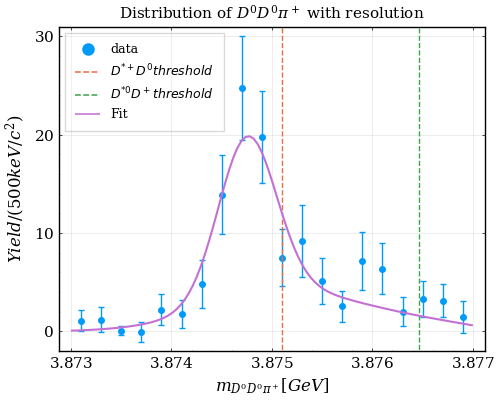

In [51]:
let
    Ev = range(3.873, 3.877, 100)
    @plt_data data_ddπ_sub title = L"Distribution of $D^0D^0\pi^+$ with resolution" xlabel = L"m_{D^0D^0\pi^+}[GeV]" ylabel = L"Yield/(500keV/c^2)" label = "data" size = (500, 400) legend = :topleft
    vline!([mDn + mDsc], ls = :dash, label = L"D^{*+}D^0 threshold")
    vline!([mDc + mDsn], ls = :dash, label = L"D^{*0}D^+ threshold")
    plot!(Ev, e -> dist(e, [fitres_V[5].values[1],fitres_V[5].values[2],fitres_V[5].values[3],fitres_V[5].values[4]]), lw = 1.5, label = "Fit")
end

In [32]:
let Ev = range(3.873, 3.877, 100)
    yields=[dist(e, [5643.42548761492,0.5103195982110288,0.4,0.0]) for e in Ev]
    df=DataFrame(X=Ev,Y=yields)
    CSV.write("./output/bestfit2.csv",df)
end

"./output/bestfit2.csv"

In [33]:
15.31817029934202/(20-1)

0.8062194894390536

In [35]:
find_poles([0.5103195982110288,0.4,0.0])|>println
find_poles([0.5103195982110288+0.0008698419253699262,0.4,0.0])|>println
find_poles([0.5103195982110288-0.0008698419253699262,0.4,0.0])|>println

-0.0003473468012393788 - 1.8522929379715042e-5im
-0.0003586290260311209 - 1.8293594386435195e-5im
-0.0003361938067047987 - 1.8756712841930826e-5im


In [36]:
-0.0003473468012393788 - 1.8522929379715042e-5im-(-0.0003586290260311209 - 1.8293594386435195e-5im)

1.1282224791742124e-5 - 2.2933499327984768e-7im

In [37]:
-0.0003473468012393788 - 1.8522929379715042e-5im-(-0.0003361938067047987 - 1.8756712841930826e-5im)

-1.1152994534580074e-5 + 2.337834622157839e-7im

# Constrained by poles

In [38]:
import Optim;

In [39]:
df_pre_paras=DataFrame(CSV.File("./output/review_lamv_Cv_schemeII.csv"));
pre_Cv=df_pre_paras.Cv;
pre_Λv=df_pre_paras.lam;

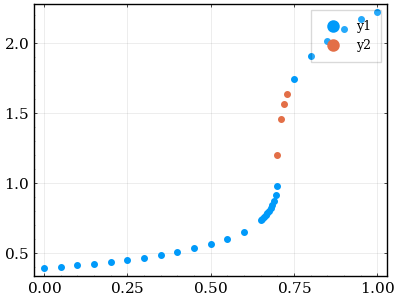

sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


In [53]:
scatter(pre_Cv,pre_Λv)
# vline!([0.71,0.72,0.73])
scatter!([0.70,0.71,0.72,0.73],[1.2000000008793346,1.4577946007555487,1.5658621823026806,1.637747247026794])

In [35]:
Λv_Cv=zeros(Float64,30);

In [58]:
let 
    function tmpf(x;Cv=0.0)
        res=find_poles([x[1],Cv,0.0])
        # isnan(res) ? 1 : abs(res-(-0.000347 - 18.5e-6im))
        isnan(res) ? 1 : abs(res-(-0.000347 - 18.5e-6im))*100
    end
    
    # for i in 1:5
    # for i in 15:30
    # for i in 18:24
    for i in 21:24
        println(i)
        tmpcv=pre_Cv[i]
        # tmpΛ=pre_Λv[i]
        tmpΛ=Λv_Cv[i]
        res=Optim.optimize(x->tmpf(x;Cv=tmpcv),[0.9*tmpΛ],[1.1*tmpΛ],[tmpΛ])
        global Λv_Cv[i]=Optim.minimizer(res)[1]
    end
end

21
22
23
24


In [59]:
Λv_Cv

30-element Vector{Float64}:
 0.3920065195913227
 0.4023092802006984
 0.4134721824916631
 0.42563719377879783
 0.43898454465178127
 0.4537479817427049
 0.47023854642003393
 0.48888338082983973
 0.5102927548991291
 0.5353845275500652
 0.5656385345868974
 0.6036913527844274
 0.6550441050951901
 ⋮
 0.8039337194244579
 0.8234392547743865
 1.0292557930140889
 1.100429628446211
 1.1459882754052835
 1.1813411160301965
 1.7406887622466967
 1.9058440809827437
 2.016135737941372
 2.099558188844987
 2.16643407180115
 2.2219380930479575

In [63]:
let 
    function tmpf(x;Cv=0.0)
        res=find_poles([x[1],Cv,0.0])
        isnan(res) ? 1 : abs(res-(-0.000347 - 18.7e-6im))*100
    end

    tmpcv=0.74
    res=Optim.optimize(x->tmpf(x;Cv=tmpcv),[1.6],[2.1],[1.8])
    println(Optim.minimizer(res)[1])
end

1.693873468382031


In [ ]:
# 0.70;1.2000000008793346
# 0.71;1.4577946007555487
# 0.72;1.5658621823026806
# 0.73;1.637747247026794
# 0.74:1.693873468382031

# Test Cv (from constrained parameters)

In [36]:
for i in 1:30
    # println(find_poles([pre_Λv[i],pre_Cv[i],0.0]))
    println(find_poles([Λv_Cv[i],pre_Cv[i],0.0]))
end

-0.00034700468263837436 - 1.8724699665307013e-5im
-0.0003470040853268408 - 1.8696363842161506e-5im
-0.000347003510265953 - 1.8668997567865164e-5im
-0.0003470029586982726 - 1.8642672383962105e-5im
-0.000347002432303789 - 1.8617470310020114e-5im
-0.00034700193268566437 - 1.859348644844833e-5im
-0.0003470014620008399 - 1.8570832595639968e-5im
-0.00034700102283879986 - 1.8549642526331316e-5im
-0.00034700061830417184 - 1.853008011364372e-5im
-0.0003470002524856852 - 1.8512352708544227e-5im
-0.0003469999308247651 - 1.849673536407223e-5im
-0.0003469996303002709 - 1.848362144964286e-5im
-0.00034699945629634854 - 1.847364320294133e-5im
-0.00034699934355497675 - 1.846813912465505e-5im
-0.00034699933958348694 - 1.8467948706424744e-5im
-0.00034699933757842416 - 1.846784948972839e-5im
-0.0003620243946205193 - 1.8164507425423874e-5im
-0.000402997372167313 - 1.7395328085142396e-5im
-0.00045694188226219623 - 1.6492306465552026e-5im
-0.0005422361695077704 - 1.5263751728007204e-5im
-0.000616678314780294

0.5521466255187986    0.45


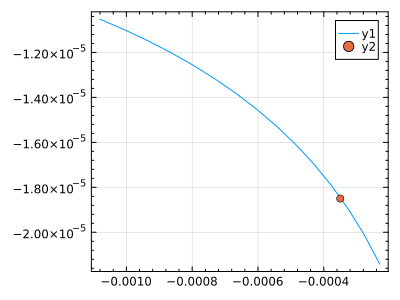

In [40]:
let nf=10
    println(pre_Λv[nf],"    ",pre_Cv[nf])
    xv=collect(range(pre_Λv[nf-1],pre_Λv[nf+1],15))
    poles_v=[find_poles([x,pre_Cv[nf],0.0]) for x in xv]
    plot(real.(poles_v),imag.(poles_v))
    scatter!([-347.4e-6],[-18.5e-6])
end

0.6906524658203123    0.6000000000000001


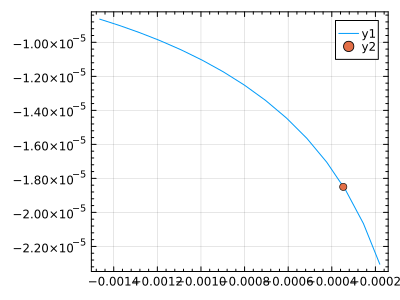

In [41]:
let nf=13
    println(pre_Λv[nf],"    ",pre_Cv[nf])
    xv=collect(range(pre_Λv[nf-1],pre_Λv[nf+1],15))
    poles_v=[find_poles([x,pre_Cv[nf],0.0]) for x in xv]
    plot(real.(poles_v),imag.(poles_v))
    scatter!([-347.4e-6],[-18.5e-6])
end

2.2969007092584848    0.9500000000000001


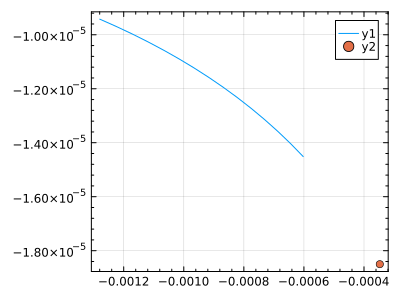

In [44]:
let nf=29
    println(pre_Λv[nf],"    ",pre_Cv[nf])
    xv=collect(range(pre_Λv[nf-1],pre_Λv[nf+1],15))
    poles_v=[find_poles([x,pre_Cv[nf],0.0]) for x in xv]
    plot(real.(poles_v),imag.(poles_v))
    scatter!([-347.4e-6],[-18.5e-6])
end

In [61]:
poles_schemeII=[find_poles([Λv_Cv[i],pre_Cv[i],0.0]) for i in 1:30];

In [63]:
poles_schemeII[21:24]

4-element Vector{ComplexF64}:
  -0.0005875741768446296 - 1.4690985353433914e-5im
  -0.0005291566693372829 - 1.5442557363891733e-5im
 -0.00045625157307638275 - 1.6510761428513922e-5im
  -0.0003856166843378972 - 1.7723807663152154e-5im

In [78]:
# find_poles([0.8459589670533861,pre_Cv[21],0.0])
# find_poles([0.8747160419148833,pre_Cv[22],0.0])
# find_poles([0.9136966134111201,pre_Cv[23],0.0])
find_poles([0.9792660157355169,pre_Cv[24],0.0])

-0.0003457671590867406 - 1.8499999999997634e-5im

In [77]:
let
    nf=24
    # find_poles([Λv_Cv[nf]-0.19,pre_Cv[nf],0.0])
    Roots.find_zero(x->imag(find_poles([x,pre_Cv[nf],0.0]))-(-18.5e-6),(Λv_Cv[nf]-0.25,Λv_Cv[nf]-0.15))
end

0.9792660157355169

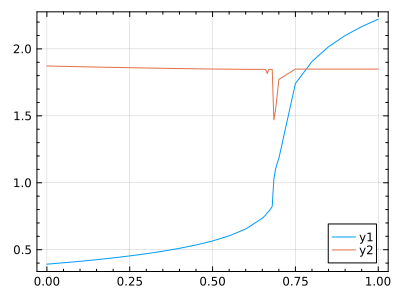

In [62]:
plot()
plot(pre_Cv,Λv_Cv)
plot!(pre_Cv,imag.(poles_schemeII)*(-1e5))

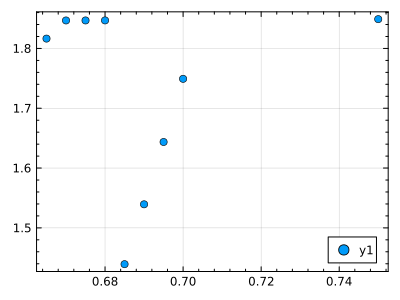

In [52]:
scatter(pre_Cv[17:25],imag.(poles_schemeII[17:25])*(-1e5))

# Extract data

In [80]:
Λv_Cv[21:24]=[0.8459589670533861,0.8747160419148833,0.9136966134111201,0.9792660157355169]

4-element Vector{Float64}:
 0.8459589670533861
 0.8747160419148833
 0.9136966134111201
 0.9792660157355169

In [83]:
Λv_Cv

30-element Vector{Float64}:
 0.3920065195913227
 0.4023092802006984
 0.4134721824916631
 0.42563719377879783
 0.43898454465178127
 0.4537479817427049
 0.47023854642003393
 0.48888338082983973
 0.5102927548991291
 0.5353845275500652
 0.5656385345868974
 0.6036913527844274
 0.6550441050951901
 ⋮
 0.8039337194244579
 0.8234392547743865
 0.8459589670533861
 0.8747160419148833
 0.9136966134111201
 0.9792660157355169
 1.7406887622466967
 1.9058440809827437
 2.016135737941372
 2.099558188844987
 2.16643407180115
 2.2219380930479575

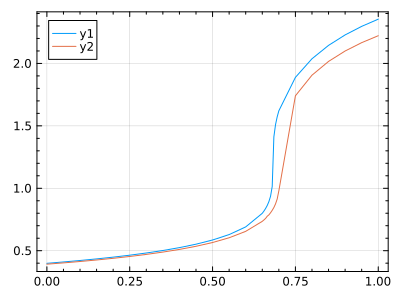

KeyError: KeyError: key "usage_request" not found

KeyError: KeyError: key "usage_request" not found

KeyError: KeyError: key "usage_request" not found

KeyError: KeyError: key "usage_request" not found

In [81]:
plot(pre_Cv,pre_Λv)
plot!(pre_Cv,Λv_Cv)

In [82]:
fitres_V3=Array{Any}(undef,30);

KeyError: KeyError: key "usage_request" not found

In [110]:
# for i in 1:5
for i in 26:30
    println(i)
    _n,_lam,_Cv,_Cp=[10000,Λv_Cv[i],pre_Cv[i],0.0]
    tmp_model=piminuit.Minuit(fcn,N=_n,lam=_lam,cv=_Cv,cp=_Cp,name=("N","lam","cv","cp"))
#     set!(tmp_model.limits,"N",(10000,30000))
    set!(tmp_model.limits,"lam",(0.98*_lam,1.02*_lam))
    set!(tmp_model.fixed,"cv",true)
    set!(tmp_model.fixed,"cp",true)
    fitres_V3[i]=piminuit.Minuit.migrad(tmp_model) 
end

26
27
28
29
30


KeyError: KeyError: key "usage_request" not found

In [112]:
[fitres_V3[i].fval for i in 1:30]

30-element Vector{Float64}:
 15.300250560198025
 15.30492523656362
 15.308953909393072
 15.312321918669006
 15.315014827731487
 15.316973765608743
 15.318202783415002
 15.318635560593547
 15.318206398193738
 15.31682367080385
 15.314341287680724
 15.310519122329938
 15.304866645115666
  ⋮
 15.289351679686726
 15.287561130998155
 15.285496456362516
 15.283070948217771
 15.279989032647874
 15.275291938973144
 15.249988841695155
 15.248062029011198
 15.246980322248772
 15.24628825834059
 15.245810432602621
 15.24547087670205

In [114]:
[fitres_V3[i].values[1] for i in 1:30]

30-element Vector{Float64}:
 8967.939568121186
 8545.073914116234
 8125.79575883185
 7709.383593363222
 7295.506780189352
 6882.10968123738
 6470.572031106543
 6058.875834861619
 5645.63787864155
 5229.057853957953
 4805.80615548747
 4370.550823564103
 3912.340815971322
    ⋮
 3105.726524388658
 3037.9319532733034
 2964.9201681838995
 2885.868569814366
 2796.0055180556787
 2682.695297164905
 3646.6962181413264
 4578.686602000212
 5520.69780511075
 6503.019434199756
 7534.452043234582
 8618.511383308425

In [115]:
[fitres_V3[i].values[2] for i in 1:30]

30-element Vector{Float64}:
 0.39202714261761346
 0.4023305756023845
 0.41349409063063935
 0.4256597448130147
 0.4390084401846699
 0.4537709065349939
 0.47026276394765115
 0.48890907832748115
 0.510319687741654
 0.535414116446638
 0.5656717767609472
 0.6037337158948106
 0.6550932363949894
 ⋮
 0.8040481172472637
 0.8235700615318051
 0.8467819765791187
 0.8757195402179214
 0.9150465048898061
 0.9817644379005842
 1.7408642479047818
 1.9059712291247903
 2.0162481930692615
 2.0996645537875858
 2.166540616503432
 2.2220398908446923

In [116]:
[fitres_V3[i].values[3] for i in 1:30]

30-element Vector{Float64}:
 0.0
 0.05
 0.1
 0.15000000000000002
 0.2
 0.25
 0.30000000000000004
 0.35000000000000003
 0.4
 0.45
 0.5
 0.55
 0.6000000000000001
 ⋮
 0.675
 0.68
 0.685
 0.6900000000000001
 0.6950000000000001
 0.7000000000000001
 0.75
 0.8
 0.8500000000000001
 0.9
 0.9500000000000001
 1.0

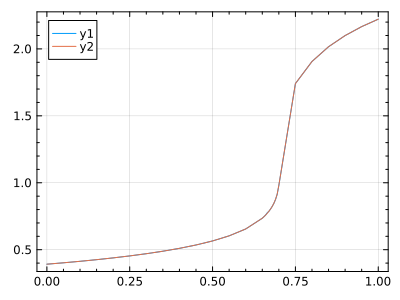

In [113]:
plot(pre_Cv,Λv_Cv)
plot!(pre_Cv[1:30],[fitres_V3[i].values[2] for i in 1:30])

In [ ]:
[fcn(x,y,z,l; fitrange = ()) for i in 1:30]

In [117]:
CSV.write("./output/review_lamv_Cv_schemeII.csv",DataFrame(N=[fitres_V3[i].values[1] for i in 1:30]
        ,lam=[fitres_V3[i].values[2] for i in 1:30],Cv=[fitres_V3[i].values[3] for i in 1:30]
        ,chisq=[fitres_V3[i].fval for i in 1:30]))

"./output/review_lamv_Cv_schemeII.csv"

KeyError: KeyError: key "usage_request" not found

In [118]:
poles_schemeII_2=[find_poles([fitres_V3[i].values[2],pre_Cv[i],0.0]) for i in 1:30];

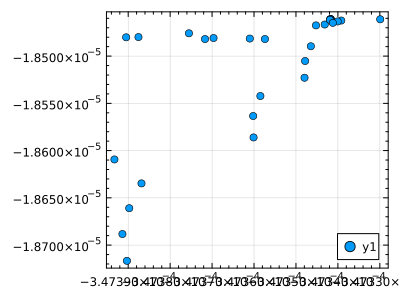

In [119]:
scatter(real.(poles_schemeII_2),imag.(poles_schemeII_2))

In [120]:
poles_schemeII_2

30-element Vector{ComplexF64}:
 -0.00034739029751529316 - 1.871665334568725e-5im
  -0.0003473913736709022 - 1.8688294962667495e-5im
  -0.0003473897464392195 - 1.866096238555143e-5im
 -0.00034738682822332834 - 1.8634697581798273e-5im
 -0.00034739328259369984 - 1.8609361394454744e-5im
 -0.00034736010807501216 - 1.8586064257204044e-5im
 -0.00034736020136261203 - 1.856340742751462e-5im
 -0.00034735848129052727 - 1.8542251836844028e-5im
  -0.0003473479558673276 - 1.8522905548117303e-5im
   -0.000347347816937571 - 1.8505179666202847e-5im
  -0.0003473464467589338 - 1.8489589189675976e-5im
 -0.00034737551925489996 - 1.8475874492979273e-5im
 -0.00034734313708195685 - 1.846656443498562e-5im
                         ⋮
 -0.00034734183031392973 - 1.84611895391254e-5im
  -0.0003473419118544818 - 1.8461628918815767e-5im
  -0.0003473392003385811 - 1.846235390582917e-5im
 -0.00034734004644576544 - 1.846332825092943e-5im
 -0.00034734121152357744 - 1.846482471499843e-5im
  -0.0003473452271514077 - 1.8467

KeyError: KeyError: key "usage_request" not found

KeyError: KeyError: key "usage_request" not found

KeyError: KeyError: key "usage_request" not found

KeyError: KeyError: key "usage_request" not found

KeyError: KeyError: key "usage_request" not found

# Getting data for revision

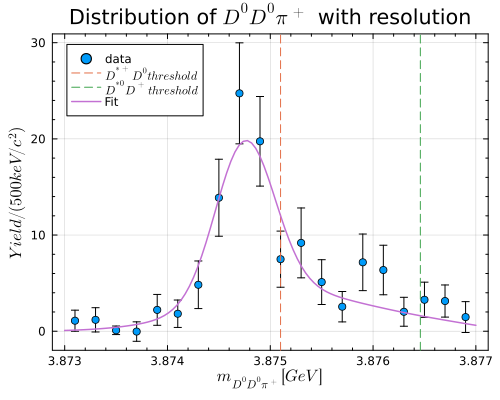

In [30]:
# baseline
let
    Ev = range(3.873, 3.877, 100)
    @plt_data data_ddπ_sub title = L"Distribution of $D^0D^0\pi^+$ with resolution" xlabel = L"m_{D^0D^0\pi^+}[GeV]" ylabel = L"Yield/(500keV/c^2)" label = "data" size = (500, 400) legend = :topleft
    vline!([mDn + mDsc], ls = :dash, label = L"D^{*+}D^0 threshold")
    vline!([mDc + mDsn], ls = :dash, label = L"D^{*0}D^+ threshold")
    plot!(Ev, e -> dist(e, [8967.939568121186,0.39202714261761346,0.0,0.0]), lw = 1.5, label = "Fit")
end

In [31]:
let Ev = range(3.873, 3.877, 100)
    yields=[dist(e, [8967.939568121186,0.39202714261761346,0.0,0.0]) for e in Ev]
    df=DataFrame(X=Ev,Y=yields)
    CSV.write("./output/fit2_review.csv",df)
end

"./output/fit2_review.csv"

# Others

In [64]:
let 
    _n,_lam,_Cv,_Cp=[10000,1.693873468382031,0.74,0.0]
    tmp_model=piminuit.Minuit(fcn,N=_n,lam=_lam,cv=_Cv,cp=_Cp,name=("N","lam","cv","cp"))
    set!(tmp_model.fixed,"cv",true)
    set!(tmp_model.fixed,"cp",true)
    global fitres=piminuit.Minuit.migrad(tmp_model) 
end

PyObject <FMin algorithm='Migrad' edm=0.00019412198964657745 edm_goal=0.0002 errordef=1.0 fval=15.250872280073132 has_accurate_covar=True has_covariance=True has_made_posdef_covar=False has_parameters_at_limit=False has_posdef_covar=True has_reached_call_limit=False has_valid_parameters=True hesse_failed=False is_above_max_edm=False is_valid=True nfcn=37 ngrad=0 reduced_chi2=nan time=308.9929588340019>
(Param(number=0, name='N', value=3461.3578732695205, error=368.29504663462296, merror=None, is_const=False, is_fixed=False, lower_limit=None, upper_limit=None), Param(number=1, name='lam', value=1.6940583102333022, error=0.0058873733307066595, merror=None, is_const=False, is_fixed=False, lower_limit=None, upper_limit=None), Param(number=2, name='cv', value=0.74, error=0.0074, merror=None, is_const=False, is_fixed=True, lower_limit=None, upper_limit=None), Param(number=3, name='cp', value=0.0, error=0.1, merror=None, is_const=False, is_fixed=True, lower_limit=None, upper_limit=None))
[[1.35641241e+05 2.82617554e-01 0.00000000e+00 0.00000000e+00]
 [2.82617554e-01 3.46611647e-05 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]]

In [56]:
#0.70
println(fitres.values)
println(fitres.fval)

PyObject <ValueView N=2682.42932861715 lam=0.981792393791535 cv=0.7 cp=0.0>
15.27528909281419


In [58]:
#0.71
println(fitres.values)
println(fitres.fval)

PyObject <ValueView N=2820.612875420939 lam=1.4582719887682067 cv=0.71 cp=0.0>
15.255407089781954


In [60]:
#0.72
println(fitres.values)
println(fitres.fval)

PyObject <ValueView N=3053.798735165406 lam=1.566153973489664 cv=0.72 cp=0.0>
15.252985738406515


In [62]:
#0.73
println(fitres.values)
println(fitres.fval)

PyObject <ValueView N=3260.7600802168095 lam=1.6379776014872585 cv=0.73 cp=0.0>
15.251631989612866


In [65]:
#0.74
println(fitres.values)
println(fitres.fval)

PyObject <ValueView N=3461.3578732695205 lam=1.6940583102333022 cv=0.74 cp=0.0>
15.250872280073132


In [ ]:
scatter!([0.70,0.71,0.72,0.73],[1.2000000008793346,1.4577946007555487,1.5658621823026806,1.637747247026794])